In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from lime.lime_tabular import LimeTabularExplainer

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import optuna

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. DATA CLEANING I PRZYGOTOWANIE (EDA)

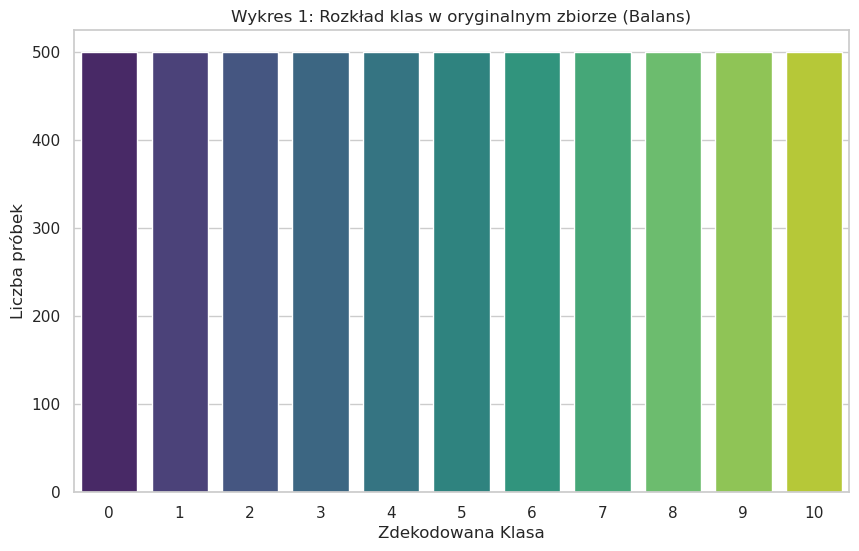

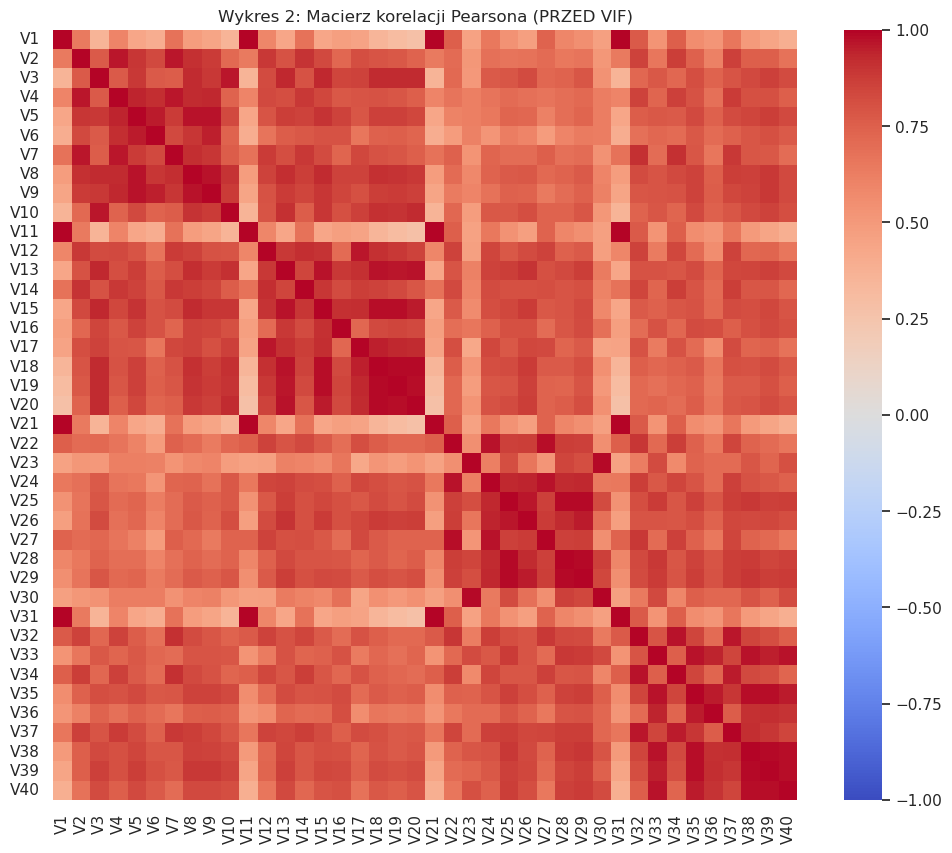

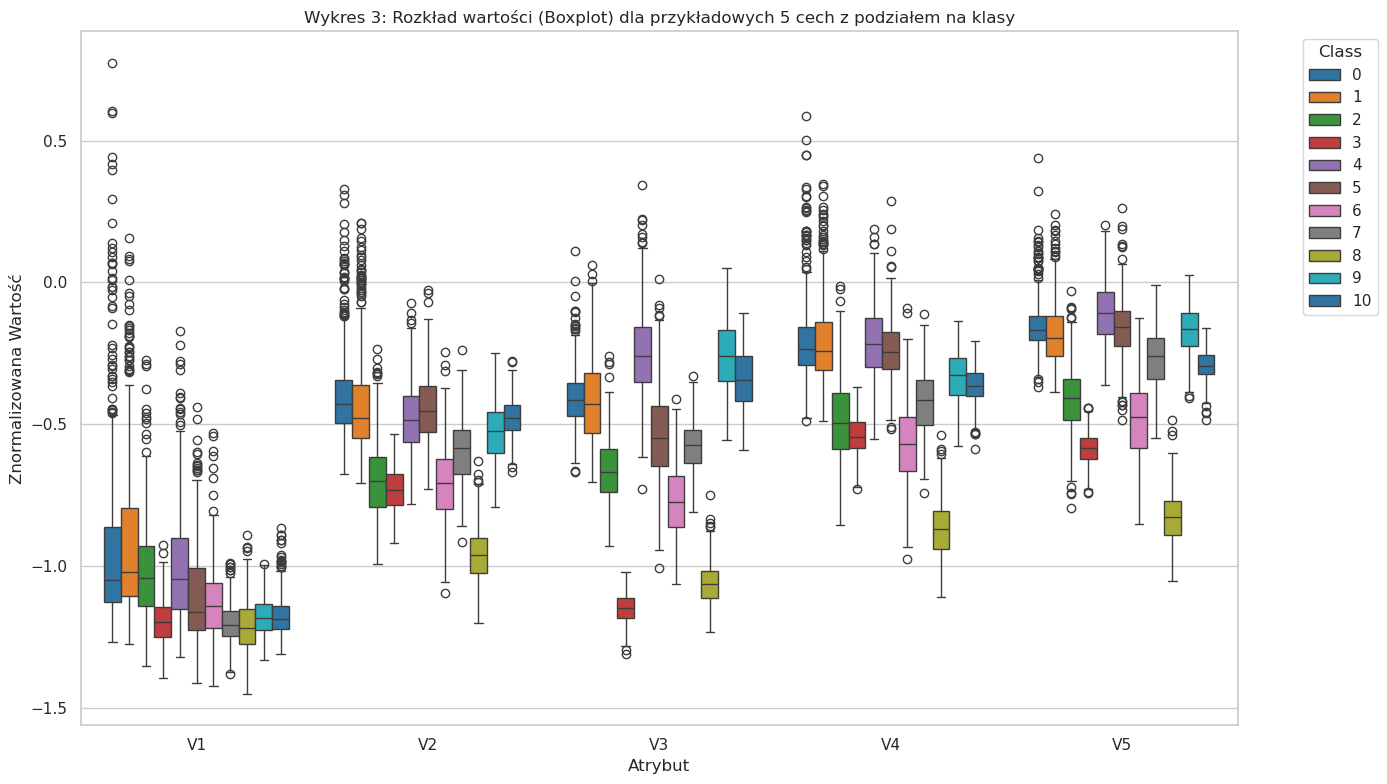

Iteracja 1: Usunięto cechę V1 z VIF = inf
Iteracja 2: Usunięto cechę V11 z VIF = inf
Iteracja 3: Usunięto cechę V21 z VIF = inf
Iteracja 4: Usunięto cechę V35 z VIF = 5043.19
Iteracja 5: Usunięto cechę V34 z VIF = 4373.41
Iteracja 6: Usunięto cechę V18 z VIF = 3726.11
Iteracja 7: Usunięto cechę V38 z VIF = 3284.22
Iteracja 8: Usunięto cechę V19 z VIF = 2426.48
Iteracja 9: Usunięto cechę V14 z VIF = 1916.63
Iteracja 10: Usunięto cechę V37 z VIF = 1833.75
Iteracja 11: Usunięto cechę V28 z VIF = 1679.11
Iteracja 12: Usunięto cechę V39 z VIF = 1337.73
Iteracja 13: Usunięto cechę V22 z VIF = 1288.53
Iteracja 14: Usunięto cechę V29 z VIF = 1218.41
Iteracja 15: Usunięto cechę V12 z VIF = 1086.83
Iteracja 16: Usunięto cechę V27 z VIF = 995.26
Iteracja 17: Usunięto cechę V25 z VIF = 902.28
Iteracja 18: Usunięto cechę V7 z VIF = 715.86
Iteracja 19: Usunięto cechę V15 z VIF = 701.37
Iteracja 20: Usunięto cechę V2 z VIF = 460.90
Iteracja 21: Usunięto cechę V20 z VIF = 415.92
Iteracja 22: Usunięto 

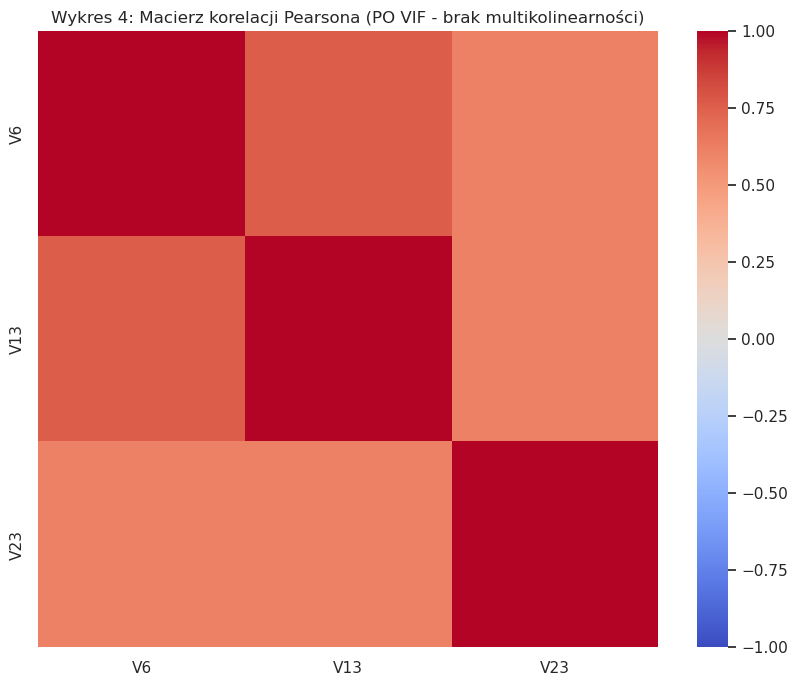

In [18]:
data, meta = arff.loadarff('phpBDgUyY.arff')
df = pd.DataFrame(data)
df = df.dropna()

le = LabelEncoder()#zamiana nazw klas na liczby całkowite
df['Class'] = le.fit_transform(df['Class'].astype(str))

X = df.drop(columns=['Class'])
y = df['Class']


plt.figure()
sns.countplot(x=y, palette="viridis")
plt.title("Wykres 1: Rozkład klas w oryginalnym zbiorze (Balans)")
plt.xlabel("Zdekodowana Klasa")
plt.ylabel("Liczba próbek")
plt.show()


plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Wykres 2: Macierz korelacji Pearsona (PRZED VIF)")
plt.show()


subset_cols = X.columns[:5]
plt.figure(figsize=(14, 8))
melted_df = pd.melt(df, id_vars=['Class'], value_vars=subset_cols)
sns.boxplot(x='variable', y='value', hue='Class', data=melted_df, palette="tab10")
plt.title("Wykres 3: Rozkład wartości (Boxplot) dla przykładowych 5 cech z podziałem na klasy")
plt.xlabel("Atrybut")
plt.ylabel("Znormalizowana Wartość")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Class")
plt.tight_layout()
plt.show()

#VIF > 10 - silna korelacja miedzy cechami
def remove_collinear_features_iterative(X_df, threshold=10.0):
    X_cleaned = X_df.copy()
    iteration = 1
    while True:
        #vif dla jednej zmiennej zalezy od wszystkich pozostalych zmiennych
        #dlatego robimy to iteracyjnie, usuwamy one at the time, ponieważ
        #usuniecie jednej moze spowodowac ze ta kolejna spadnie do bezpiecznego poziomu
        vif_values = [variance_inflation_factor(X_cleaned.values, i) for i in range(X_cleaned.shape[1])]
        max_vif = max(vif_values)
        
        if max_vif > threshold:
            max_idx = np.argmax(vif_values)
            max_feature = X_cleaned.columns[max_idx]
            print(f"Iteracja {iteration}: Usunięto cechę {max_feature} z VIF = {max_vif:.2f}")
            X_cleaned = X_cleaned.drop(columns=[max_feature])
            iteration += 1
        else:
            print("Zakończono analizę VIF. Wszystkie pozostałe cechy mają VIF <", threshold)
            break
    return X_cleaned

X_cleaned = remove_collinear_features_iterative(X, threshold=10.0)


plt.figure(figsize=(10, 8))
sns.heatmap(X_cleaned.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Wykres 4: Macierz korelacji Pearsona (PO VIF - brak multikolinearności)")
plt.show()


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_cleaned, y, test_size=0.2, stratify=y
)

scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

# 2. DATALOADERY I WEIGHTED RANDOM SAMPLER

In [19]:
class TextureDataset(Dataset):#tlumaczenie dane z Numpy i Pandas na tenosry
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y.values if isinstance(y, pd.Series) else y)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_dataloader(X, y, batch_size=64, is_train=True):
    dataset = TextureDataset(X, y)
    if is_train:
        class_counts = np.bincount(y)
        class_weights = 1.0 / (class_counts + 1e-8)
        sample_weights = class_weights[y]
        #oblicza wagi dla kazdej z klas, im mniej danych ma klasa tym
        #wieksza waga, efekt: po rowno kazdej klasy,
        #replacement= true pozwoala na losowanie tej samej probki wielokrotnie
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        return DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    else:#podczas testowania i walitacji tego nie robimy, w tej samej kolejnosci wiec suffle=false
        return DataLoader(dataset, batch_size=batch_size, shuffle=False)

# 3. MODEL PYTORCH LIGHTNING

In [20]:
class TextureClassifier(pl.LightningModule):
    def __init__(self, input_dim, num_classes, hidden_dim, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),#warstwy wejciowe ukryte
            nn.ReLU(),#fukncja aktywacji, do prowadzenia nielinowosci
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)#liczba neuronow = liczba klas
        )
        #dla klastfikacji wieloklasowej
        self.loss_fn = nn.CrossEntropyLoss()
        

        self.train_losses = []
        self.val_losses = []
        self.epoch_train_losses = []
        #przelacznie cpu/gpu, logowanie wyinikow itd
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('train_loss', loss)
        self.epoch_train_losses.append(loss.item())
        return loss

    def on_train_epoch_end(self):
        if self.epoch_train_losses:
            avg_loss = sum(self.epoch_train_losses) / len(self.epoch_train_losses)
            self.train_losses.append(avg_loss)
            self.epoch_train_losses = []
    
    def validation_step(self, batch, batch_idx):#lightning sam przelacza 
        #w tryp .eval() i wylacza liczenie gradientow
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        val_loss = self.trainer.callback_metrics.get('val_loss')
        if val_loss is not None:
            self.val_losses.append(val_loss.item())
        
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# 4. OPTYMALIZACJA HIPERPARAMETRÓW (OPTUNA)

In [21]:
def objective(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = 64 #Zamrożony batch size
    

    kf = KFold(n_splits=5, shuffle=True) 
    fold_losses = []
    
    for train_idx, val_idx in kf.split(X_train_val_scaled):
        X_train_fold = X_train_val_scaled[train_idx]
        y_train_fold = y_train_val.iloc[train_idx].values if hasattr(y_train_val, 'iloc') else y_train_val[train_idx]
        X_val_fold = X_train_val_scaled[val_idx]
        y_val_fold = y_train_val.iloc[val_idx].values if hasattr(y_train_val, 'iloc') else y_train_val[val_idx]
        
        train_loader = create_dataloader(X_train_fold, y_train_fold, batch_size, is_train=True)
        val_loader = create_dataloader(X_val_fold, y_val_fold, batch_size, is_train=False)
        
        model = TextureClassifier(input_dim=X_train_val_scaled.shape[1], num_classes=11, hidden_dim=hidden_dim, lr=lr)
        #zapamietuje moment w ktorym model osiagnal najlepszy czyli najzniszy blad
        checkpoint_callback = ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1)
        trainer = pl.Trainer(max_epochs=8, enable_progress_bar=False, logger=False, callbacks=[checkpoint_callback])
        trainer.fit(model, train_loader, val_loader)
        
        fold_losses.append(checkpoint_callback.best_model_score.item())
        
    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize')#najmniejszy bląd
study.optimize(objective, n_trials=30) 
best_params = study.best_params
print("Najlepsze parametry:", best_params)

[I 2026-06-23 10:22:04,136] A new study created in memory with name: no-name-a34321f8-e6b1-4d1e-8472-895ec860e7ae
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │  2.7 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.7 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.7 K                                                                                                
Total estimated model params size (MB): 0.011                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=8` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │  2.7 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

...

`Trainer.fit` stopped: `max_epochs=8` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │    843 │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 843                                                                                              
Non-trainable params: 0                                                                                            
Total params: 843                                                                                                  
Total estimated model params size (MB): 0.003                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=8` reached.
[I 2026-06-23 10:24:51,593] Trial 29 finished with value: 0.650544798374176 and parameters: {'hidden_dim': 32, 'lr': 0.003204314979347422}. Best is trial 18 with value: 0.6237009525299072.


Najlepsze parametry: {'hidden_dim': 128, 'lr': 0.004528121831604553}


# 5. TRENING DOCELOWY I KALIBRACJA

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │  9.5 K │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 9.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.5 K                                                                                                
Total estimated model params size (MB): 0.038                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


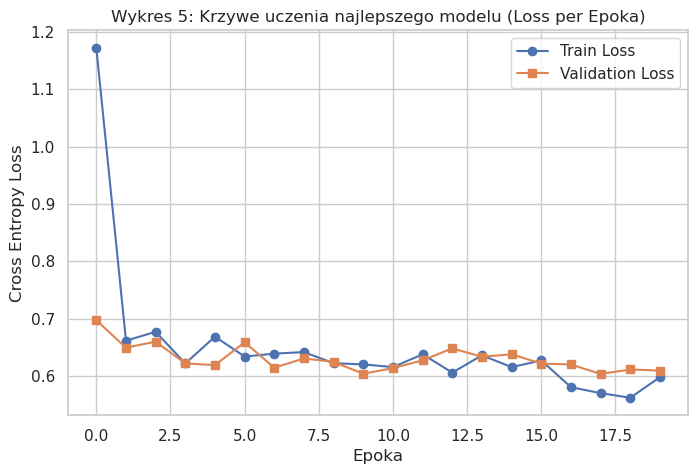

CalibratedClassifierCV(cv='prefit',
                       estimator=BulletproofSklearnWrapper(classes=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                                                           pl_model=TextureClassifier(
  (model): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=11, bias=True)
  )
  (loss_fn): CrossEntropyLoss()
)),
                       method='isotonic')

In [22]:
import torch.nn.functional as F

X_t, X_cal, y_t, y_cal = train_test_split(X_train_val_scaled, y_train_val, test_size=0.2, stratify=y_train_val)#zbalansowane proporcje klas

train_loader = create_dataloader(X_t, y_t, batch_size=64, is_train=True)
val_loader = create_dataloader(X_cal, y_cal, batch_size=64, is_train=False)
test_loader = create_dataloader(X_test_scaled, y_test, batch_size=64, is_train=False)

best_model = TextureClassifier(input_dim=X_train_val_scaled.shape[1], num_classes=11, **best_params)
checkpoint_callback = ModelCheckpoint(dirpath='checkpoints', filename='best_model', monitor='val_loss', mode='min')
trainer = pl.Trainer(max_epochs=20, callbacks=[checkpoint_callback])
trainer.fit(best_model, train_loader, val_loader)


val_losses_clean = best_model.val_losses[1:] if len(best_model.val_losses) > len(best_model.train_losses) else best_model.val_losses

plt.figure(figsize=(8, 5))
plt.plot(best_model.train_losses, label='Train Loss', marker='o')
plt.plot(val_losses_clean, label='Validation Loss', marker='s')
plt.title("Wykres 5: Krzywe uczenia najlepszego modelu (Loss per Epoka)")
plt.xlabel("Epoka")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.show()


best_model = TextureClassifier.load_from_checkpoint(checkpoint_callback.best_model_path)
best_model.eval()


class BulletproofSklearnWrapper(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(self, pl_model, classes):
        self.pl_model = pl_model
        self.classes = classes

    def fit(self, X, y=None):
        self.classes_ = np.array(self.classes)
        return self

    def predict_proba(self, X):
        #pobieramy dane w formacie numpy pandas  izmieniamy je w tensory
        #wysylamy na odpowiednie urzadzenie i przepuszczamy przez siec
        #na uzyskane logity nakladamy funkcje Softmax, zmieniamy je na
        #prawdopodobienstwa, ktore sumuja sei do 100% i zwracamy jako tablice numpy
        self.pl_model.eval()
        with torch.no_grad():
            if isinstance(X, pd.DataFrame):
                X_tensor = torch.FloatTensor(X.values)
            elif isinstance(X, np.ndarray):
                X_tensor = torch.FloatTensor(X)
            else:
                X_tensor = torch.FloatTensor(np.array(X))
                
            X_tensor = X_tensor.to(self.pl_model.device)
            logits = self.pl_model(X_tensor)
            probs = F.softmax(logits, dim=1)
        return probs.cpu().numpy()

    def predict(self, X):
        
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

    def __sklearn_is_fitted__(self):
        return True

unique_classes = np.unique(y_train_val)
base_classifier = BulletproofSklearnWrapper(best_model, classes=unique_classes)
base_classifier.fit(X_cal)
#method isotonic - uzywamy regresji izotonicznej, aby wyprostowac przeiwdywane
#prawdopodobienstwa, tak aby odwzierciedalaly rzeczywista szanse na 
#poprawna klasyfikacje
#cv = prefit - zeby base classifier nie trenowal od nowa modelu
calibrated_clf = CalibratedClassifierCV(estimator=base_classifier, method='isotonic', cv='prefit')
calibrated_clf.fit(X_cal, y_cal)

# 6. OCENA MODELU I NIEPEWNOŚĆ

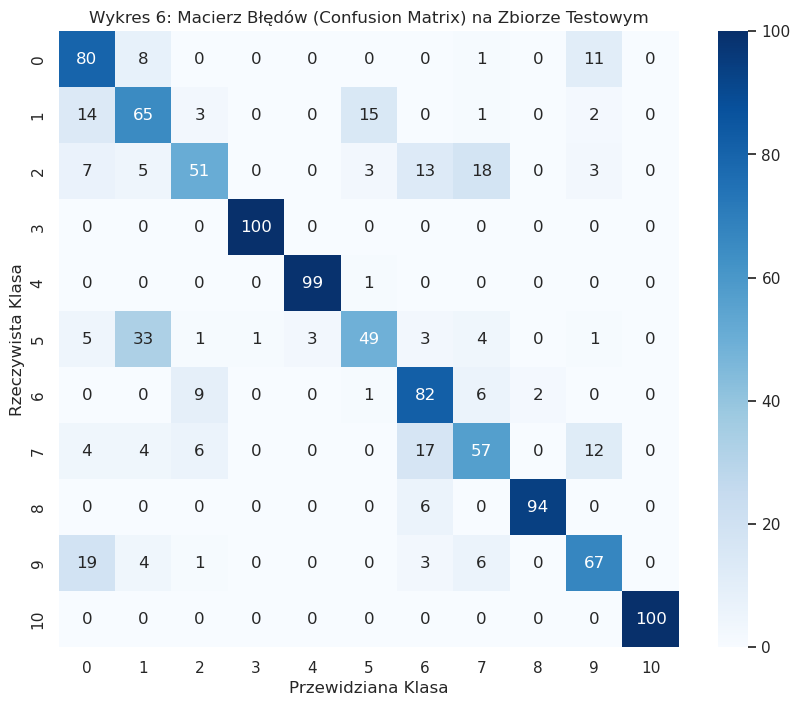

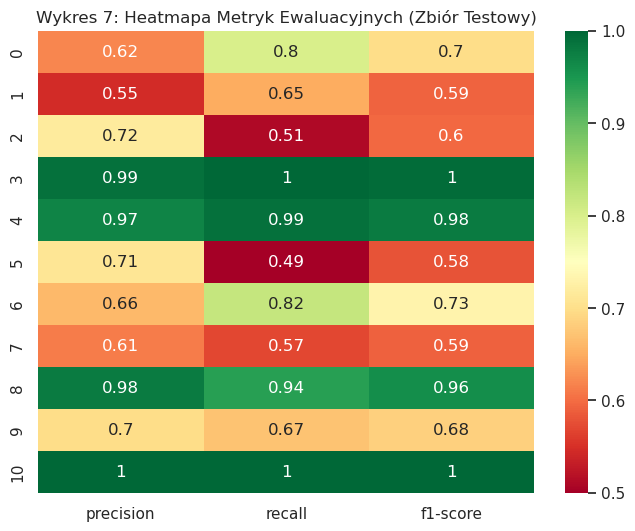

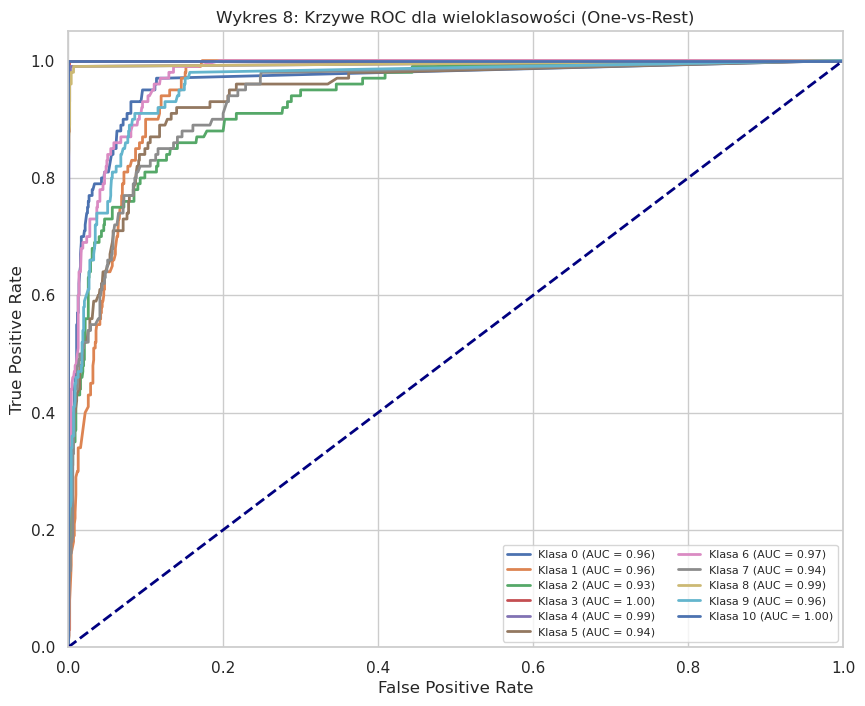

In [23]:
test_probs = calibrated_clf.predict_proba(X_test_scaled)
test_preds = calibrated_clf.predict(X_test_scaled)
#liczymy entropie Shannona, niska entropia to duza pewnosc
entropy = -np.sum(test_probs * np.log(test_probs + 1e-10), axis=1)

most_uncertain_idx = np.argmax(entropy)
most_certain_idx = np.argmin(entropy)


cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Wykres 6: Macierz Błędów (Confusion Matrix) na Zbiorze Testowym')
plt.xlabel('Przewidziana Klasa')
plt.ylabel('Rzeczywista Klasa')
plt.show()

#Precision mówi, jak wielu spośród wskazanych przez model pozytywów możesz naprawdę ufać
#recall określa, jaką część wszystkich faktycznych pozytywów model zdołał odnaleźć
# accuracy podaje ogólny odsetek poprawnych decyzji modelu, 
#f1-score to sprawiedliwa średnia, która pokazuje, jak dobrze model balansuje między precyzją a wykrywaniem.
report = classification_report(y_test, test_preds, output_dict=True)
report_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

plt.figure(figsize=(8, 6))
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='RdYlGn', vmin=0.5, vmax=1.0)
plt.title("Wykres 7: Heatmapa Metryk Ewaluacyjnych (Zbiór Testowy)")
plt.show()


y_test_bin = label_binarize(y_test, classes=unique_classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Klasa {unique_classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Wykres 8: Krzywe ROC dla wieloklasowości (One-vs-Rest)')
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.show()

# 7. EXPLAINABILITY (PFI & LIME)

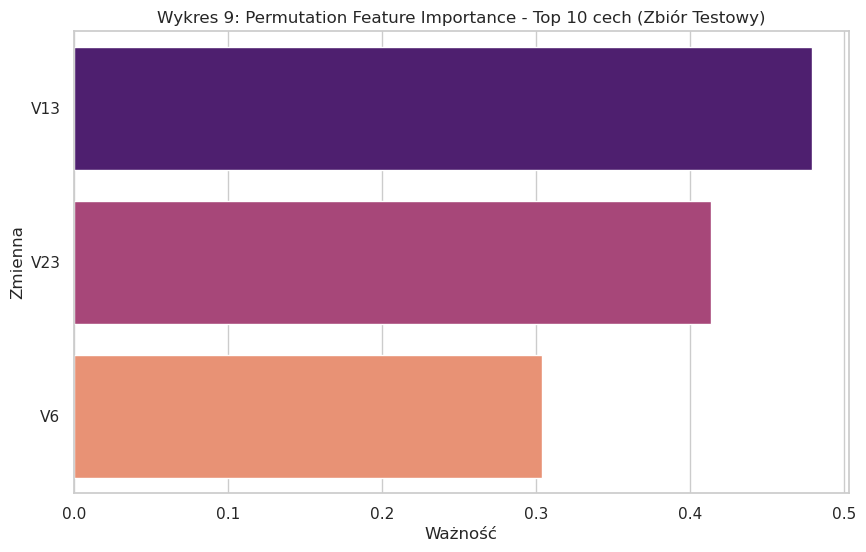

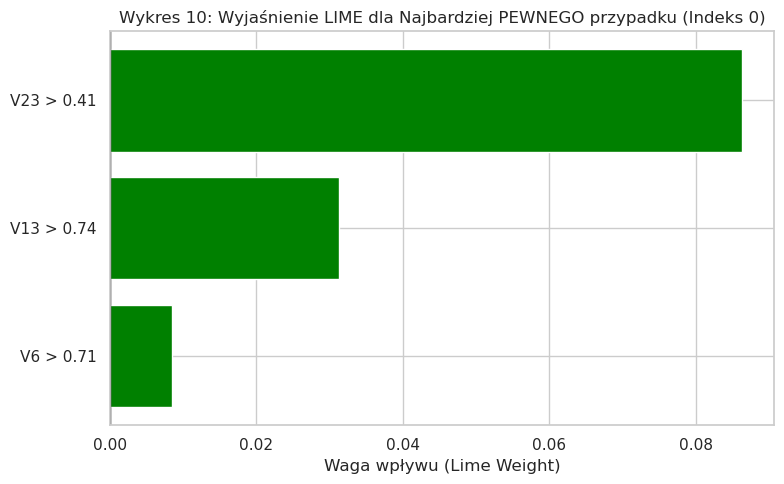

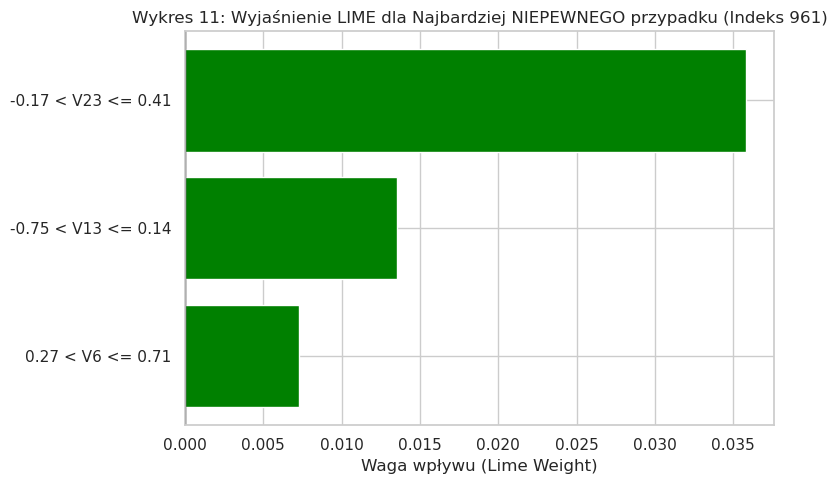

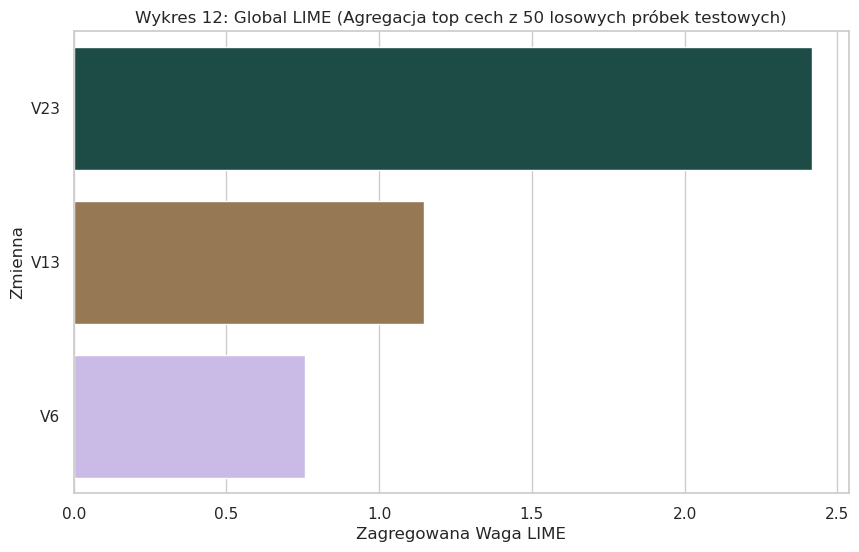

In [24]:
#bierzemy jedna ceche ze zbioru testowe, tasujemy ja, i sprawdzamy jak bardzo spadnie skutecznosc modelu, jesli skutecznosc spadl to cecha byla
#bardzo wazna dla modelu
pfi_test = permutation_importance(calibrated_clf, X_test_scaled, y_test, n_repeats=5)
feature_names = X_cleaned.columns.tolist()

pfi_df = pd.DataFrame({'Zmienna': feature_names, 'Ważność': pfi_test.importances_mean})
pfi_df = pfi_df.sort_values(by='Ważność', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Ważność', y='Zmienna', data=pfi_df, palette='magma')
plt.title("Wykres 9: Permutation Feature Importance - Top 10 cech (Zbiór Testowy)")
plt.show()

#LIME (Local Interpretable Model-agnostic Explanations)
#lime wyjasnia lokalnie, dlaczgego model podjal taka a nie inna decyzje
#dla tego jednego konkretnego wypadku, bombarduje model zniekszalconami wersjami probki
#i patrzy jak reaguja predykcje, na tej podstawie buduje prosty liniowy model
#dla tej okolicy
#w kodzie wybieramy przypadke z najmniejsza i najwieksza entropia
#globalne lib- skrypt dodaje wyniki z 50 losowych probek aby wyciagnac globalne wnioski i udowosnosci ze pokrywaja sie one z PFI
explainer = LimeTabularExplainer(
    training_data=X_t,
    feature_names=feature_names,
    class_names=[str(i) for i in unique_classes],
    mode='classification'
)

def plot_lime_explanation(exp_list, title):
    features = [x[0] for x in exp_list]
    weights = [x[1] for x in exp_list]
    colors = ['green' if w > 0 else 'red' for w in weights]
    
    plt.figure(figsize=(8, 5))
    plt.barh(features, weights, color=colors)
    plt.axvline(0, color='black', linewidth=1)
    plt.title(title)
    plt.xlabel('Waga wpływu (Lime Weight)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

exp_certain = explainer.explain_instance(X_test_scaled[most_certain_idx], calibrated_clf.predict_proba, num_features=5)
plot_lime_explanation(exp_certain.as_list(), f"Wykres 10: Wyjaśnienie LIME dla Najbardziej PEWNEGO przypadku (Indeks {most_certain_idx})")


exp_uncertain = explainer.explain_instance(X_test_scaled[most_uncertain_idx], calibrated_clf.predict_proba, num_features=5)
plot_lime_explanation(exp_uncertain.as_list(), f"Wykres 11: Wyjaśnienie LIME dla Najbardziej NIEPEWNEGO przypadku (Indeks {most_uncertain_idx})")


global_lime_weights = {feature: 0.0 for feature in feature_names}
#wybieramy losowo podzbiór do estymacji globalnej
sample_indices = np.random.choice(len(X_test_scaled), size=min(50, len(X_test_scaled)), replace=False)

for idx in sample_indices:
    exp = explainer.explain_instance(X_test_scaled[idx], calibrated_clf.predict_proba, num_features=5)
    for feature_desc, weight in exp.as_list():
        for fn in feature_names:
            if fn in feature_desc:
                global_lime_weights[fn] += abs(weight)#abs bo nie interesuje nas kierunek
                #a sila z jaka dana cecha kierowala w danym wyniku

top_global_lime = sorted(global_lime_weights.items(), key=lambda item: item[1], reverse=True)[:10]
global_lime_df = pd.DataFrame(top_global_lime, columns=['Zmienna', 'Zagregowana Waga LIME'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Zagregowana Waga LIME', y='Zmienna', data=global_lime_df, palette='cubehelix')
plt.title("Wykres 12: Global LIME (Agregacja top cech z 50 losowych próbek testowych)")
plt.show()